# Chapter 2: From observed loss to a confirmed weak region

A model can have modest average loss while concentrating much larger errors in a small part of its population. The worked AML case follows that concern from observed outcomes to an executable regional rule, then checks the frozen rule on fresh observations. It connects the chapter's evaluation contract, adapter and evaluator to the weighted-leaf example in Section 2.7 and the handoff to search in Section 2.11.

The logistic predictor is already trained. The notebook computes its testing probabilities and observation-level Brier losses, then fits a separate depth-two XGBoost regressor to those losses. The fitted error trees supply a geometry for clustering. The notebook reconstructs that geometry, reruns the recorded four-medoid PAM construction and checks all discovery and confirmation assignments against saved evidence. It then interprets the regional loss measurements and the auxiliary model's fitted effects. The logistic predictor remains frozen. The auxiliary regressor is refitted with the recorded settings and checked against the saved trees before reuse of the recorded regional results. No LLM is called.

**Run order and evidence.** Run the cells from top to bottom in the environment described below. Later cells use objects created earlier. The numerical example uses a synthetic rare-event AML population, 40,000 discovery observations and 200,000 confirmation observations at seed 62624. Saved outputs document the executed run. Assertions check consistency with that record; their passing does not independently validate the modeling assumptions. The small A/B/C leaf example is illustrative.

The discovery observations guide the representation and the region choice. Confirmation evaluates the frozen choice. The notebook therefore keeps candidate construction, measured weakness and confirmation as separate stages. The closing discussion explains how these measurements could support ordinary search.


## Setup and source checks

Use a Python kernel with the dependencies listed in the README. The setup cell locates the data root, which holds the evidence files and helper modules. It uses `MODEL_VALIDATION_ROOT` when that variable is set. Otherwise it searches for a repository checkout containing the current directory and then for the copy installed with the `aiv` package. It prints the Python version and which of these sources it used, then reloads the helper modules from the data root so an older cached import cannot hide newly added functions. After updating the notebook or helpers, rerun setup and all subsequent cells. NumPy handles arrays, pandas displays tables and Matplotlib draws figures. The later cells also require SciPy, scikit-learn, scikit-learn-extra, joblib and XGBoost. An import failure indicates that the selected kernel needs checking before proceeding.

`BOOK` points to the `book/` directory under the data root. The six-decimal pandas display setting affects formatting only; calculations retain their original precision. The printed mode identifies this walkthrough as frozen-model prediction, auxiliary Brier-loss fitting and regional replay. This setup cell prepares imports; artifact hash checks occur when the next cell calls the loaders. A hash mismatch means the files differ from the recorded inputs and should be resolved before interpreting the replay.

The source artifacts are `book/evidence/aml_leaf_geometry_weighted_20260924/` for the geometry and confirmation run, and `book/evidence/aml_error_clustering_current_20260921/` for the shared fitted error model and discovery sample. Loading both retains their recorded relationship. The confirmation evidence used here must not be substituted into a different historical experiment.


In [1]:
from pathlib import Path
import os
import platform
import sys
import importlib.util

# Locate the data root: the directory whose relative layout the evidence records use.
MARKER = "book/notebooks/regional_case/companion.py"

def find_data_root():
    configured = os.environ.get("MODEL_VALIDATION_ROOT")
    if configured:
        root = Path(configured).expanduser().resolve()
        if not (root / MARKER).is_file():
            raise FileNotFoundError(f"MODEL_VALIDATION_ROOT must contain {MARKER}")
        return root, "MODEL_VALIDATION_ROOT"
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / MARKER).is_file():
            return path, "repository checkout"
    try:
        from aiv.companions import locate
    except ImportError:
        raise FileNotFoundError(
            "Companion data not found. Install the aiv package, open the notebook "
            "inside the repository checkout, or set MODEL_VALIDATION_ROOT.") from None
    return locate()

ROOT, DATA_SOURCE = find_data_root()
HELPERS = ROOT / "book/notebooks/regional_case"
for path in (ROOT, ROOT / "book", HELPERS):
    value = str(path)
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

# Load current helper files even if this kernel cached an older notebook revision.
def load_helper_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    try:
        spec.loader.exec_module(module)
    except Exception:
        sys.modules.pop(name, None)
        raise
    return module

load_helper_module("companion", HELPERS / "companion.py")
load_helper_module("ch02_helpers", HELPERS / "ch02_helpers.py")
load_helper_module("weighted_leaf_geometry", ROOT / "book/weighted_leaf_geometry.py")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
print("Python:", platform.python_version())
print("Data root found from:", DATA_SOURCE)
from companion import read, sha, BOOK
pd.set_option("display.float_format", "{:.6f}".format)
print("Mode: frozen predictor; fit depth-two XGBoost to Brier loss; replay regions; no live LLM")


Python: 3.12.3
Data root found from: repository checkout
Mode: frozen predictor; fit depth-two XGBoost to Brier loss; replay regions; no live LLM


## Run the frozen model on testing observations

A low average prediction error can conceal a small population with much larger error. The validation question is whether an executable rule can locate that population and whether elevated loss persists on fresh observations. Start by applying the model under test to observations excluded from its training.

The saved logistic pipeline includes its fitted preprocessing and predictor. `frozen_predictor()` checks the source artifacts and loads that pipeline. `predict_proba(Xd)[:, 1]` computes the probability of the positive AML outcome for every testing observation. The pipeline transforms the inputs with its existing parameters; there is no call to its `fit` method. Feature columns retain their recorded order.

These 40,000 rows are testing data for the frozen predictor and are called **discovery data** in the book because their errors subsequently train the auxiliary model and guide region selection. The separate confirmation sample stays outside those fitting and selection steps. `load_geometry()` and `load_clustering()` check the saved evidence and load the observations needed for the replay.

In [2]:
from ch02_helpers import load_geometry, load_clustering, frozen_predictor, auxiliary_model
from scipy.spatial.distance import cdist
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import r2_score
sys.path.insert(0, str(BOOK))
from weighted_leaf_geometry import weighted_leaf_embedding, leaf_tables
geo, geo_frozen, asg = load_geometry()
clus, obs = load_clustering()
features = clus["features"]
Xd = pd.DataFrame(obs["X_discovery"], columns=features)
y = obs["y_discovery"]
base = frozen_predictor()
p = base.predict_proba(Xd)[:, 1]
np.testing.assert_allclose(p, obs["p_discovery"], rtol=0, atol=1e-12)
assert np.isin(y, [0, 1]).all() and ((p >= 0) & (p <= 1)).all()
display(pd.DataFrame({"outcome": y[:5], "frozen-model probability": p[:5]}))
print("Testing / discovery observations:", len(Xd))

,outcome,frozen-model probability
0,0,0.018282
1,0,0.032425
2,0,0.003558
3,0,0.023103
4,0,0.007948


Testing / discovery observations: 40000


**Read the output.** Each row pairs an observed binary outcome with the probability the frozen model now computes. The first five observations are all negative outcomes with probabilities between 0.003558 and 0.032425, which is typical of a rare-event population. Agreement with the saved probabilities to within $10^{-12}$ confirms that the loaded pipeline and inputs reproduce the original predictions. The predictor has not learned from these testing outcomes; the auxiliary model will use them to study its errors.

## Calculate observation-level Brier loss

The auxiliary model needs one error target per observation (Section 2.8). For binary outcome $y_i$ and frozen-model probability $p_i$, define Brier loss as

$$L_i=(y_i-p_i)^2.$$

The residual $y_i-p_i$ is signed. Squaring gives a nonnegative loss between zero and one, so taking the absolute value of Brier loss would leave it unchanged. For a positive outcome with probability 0.8, the loss is $(1-0.8)^2=0.04$. For a negative outcome with that probability, it is $(0-0.8)^2=0.64$. These illustrative values show how a confident error receives a larger penalty.

`loss` retains all 40,000 individual targets. Its mean is the sample Brier score, a summary of predictor performance. Fitting the auxiliary model to that single mean would discard the variation needed to locate weak regions. The table exposes the residual and squared loss calculation before any fitting occurs.

In [3]:
residual = y - p
loss = residual**2
assert loss.shape == (len(Xd),) and np.isfinite(loss).all()
assert ((loss >= 0) & (loss <= 1)).all()
np.testing.assert_array_equal(np.abs(loss), loss)
np.testing.assert_allclose(loss, obs["residual_discovery"]**2, rtol=0, atol=1e-12)
display(pd.DataFrame({"outcome": y[:5], "probability": p[:5],
                      "residual": residual[:5], "Brier loss target": loss[:5]}))
print("Testing / discovery mean Brier score:", loss.mean())

,outcome,probability,residual,Brier loss target
0,0,0.018282,-0.018282,0.000334
1,0,0.032425,-0.032425,0.001051
2,0,0.003558,-0.003558,0.000013
3,0,0.023103,-0.023103,0.000534
4,0,0.007948,-0.007948,0.000063


Testing / discovery mean Brier score: 0.02096640996184518


**Read the output.** For the first five rows every outcome is zero, so the residual equals minus the probability. The Brier losses are correspondingly small, from 0.000013 to 0.001051. The mean over all 40,000 rows, the discovery Brier score, is 0.020966. Larger values indicate greater observed probability error for the frozen predictor, and the individual values retain the variation needed for conditional analysis. Brier loss includes outcome variability as well as prediction error, so elevated regional loss alone does not establish a correctable calibration defect.

## Fit depth-two XGBoost to Brier loss

The auxiliary regression estimates how the frozen predictor's loss varies with input features. It uses the original feature matrix `Xd` as inputs and the observed Brier losses `loss` as targets. Neither observed outcomes nor computed losses are appended as input features. Confirmation observations are excluded from fitting.

`XGBRegressor` builds 120 trees with maximum depth two. Each root-to-leaf path therefore uses at most two feature splits, providing a representation that can later be decomposed into main effects and pairwise interactions. The learning rate of 0.05 controls each tree's contribution. Histogram-based tree construction, a fixed random seed and full row/column sampling reproduce the recorded fitting setup.

The target and the fitting objective have distinct roles. Brier loss $L_i$ measures error of the frozen predictor. The XGBoost objective `reg:squarederror` fits an auxiliary function $g$ by penalizing $(L_i-g(x_i))^2$, together with its tree regularization. It learns to predict each observation's Brier loss. No absolute-value transform of the target is needed.

The cell fits a new auxiliary instance in memory, then compares its trees and predictions with the saved auxiliary model. This check permits the later cells to retain their recorded geometry and confirmation results. A failed comparison indicates a reproduction difference that should be investigated before interpreting those results. The saved model is a reference for the check; subsequent calculations use the newly fitted `aux`.

In [4]:
from xgboost import XGBRegressor
aux = XGBRegressor(
    n_estimators=120, max_depth=2, learning_rate=0.05,
    objective="reg:squarederror", tree_method="hist",
    n_jobs=2, random_state=62104, subsample=1.0, colsample_bytree=1.0,
)
aux.fit(Xd, loss)
reference_aux = auxiliary_model()
assert aux.get_booster().get_dump(dump_format="json") == reference_aux.get_booster().get_dump(dump_format="json")
np.testing.assert_allclose(aux.predict(Xd), reference_aux.predict(Xd), rtol=0, atol=1e-12)
display(pd.DataFrame({"observed Brier loss": loss[:5],
                      "auxiliary predicted loss": aux.predict(Xd.iloc[:5])}))
print("Trees:", aux.n_estimators, "Maximum depth:", aux.max_depth)
print("Auxiliary discovery R2:", r2_score(loss, aux.predict(Xd)))
print("Fitted trees and predictions reproduce the saved auxiliary model.")

,observed Brier loss,auxiliary predicted loss
0,0.000334,0.023307
1,0.001051,0.017214
2,0.000013,0.001518
3,0.000534,0.013773
4,0.000063,0.008189


Trees: 120 Maximum depth: 2
Auxiliary discovery R2: 0.05725842382812274
Fitted trees and predictions reproduce the saved auxiliary model.


**Read the output.** The refitted trees and predictions match the saved auxiliary model, so the later cells can reuse the recorded geometry and results. Observed and predicted loss need not agree for an individual row: the first observation has observed loss 0.000334 and predicted loss 0.023307. The discovery R² is 0.057258, so the auxiliary model explains a small fraction of the variation in individual losses. The target is noisy: most observations have losses near zero, and the large losses come from the rare positive outcomes. The R² is measured on the observations used for fitting, so it is not an independent assessment of generalization. The regression predictions are not constrained to [0, 1], although the observed targets lie there.

## Route an observation through the error trees

Observations with similar patterns of predicted error may be useful neighbors even when their raw feature values differ. The XGBoost regressor just fitted approximates discovery Brier loss using 120 depth-two trees. This is an auxiliary model of the predictor's loss, with loss as its regression target. Its tree partitions supply the representation used for clustering.

`aux.apply(Xd)` routes every discovery observation through every tree. The resulting `codes` array has shape `(40000, 120)`: a row identifies an observation and a column identifies a tree. Each entry is that tree's leaf identifier. `leaf_tables(aux)` maps leaf identifiers to their fitted regression contributions. The displayed table follows observation 0 through the first three trees; `aux.predict` includes all trees and the intercept.

In [5]:
codes = aux.apply(Xd).astype(int)
tables = leaf_tables(aux)
display(pd.DataFrame([dict(tree=t, leaf=int(codes[0,t]), value=tables[t][int(codes[0,t])]) for t in range(3)]))
print("Observed loss:", loss[0], "Auxiliary predicted loss:", aux.predict(Xd.iloc[:1])[0])
assert codes.shape == (40000, 120)

,tree,leaf,value
0,0,3,-0.000328
1,1,3,-0.000376
2,2,3,-0.000294


Observed loss: 0.0003342193911009536 Auxiliary predicted loss: 0.02330689


**Read the output.** Observation 0 reaches leaf 3 in each of the first three trees, with fitted contributions −0.000328, −0.000376 and −0.000294. A leaf ID is a category local to a tree: subtracting IDs would not measure similarity, and leaf 3 in tree 0 and leaf 3 in tree 1 are unrelated regions. A contribution can be negative because boosting adds corrections to the current prediction, and the contributions already include learning-rate shrinkage. Summed over all 120 trees with the intercept, they give the auxiliary prediction 0.023307 for this observation.

## Keep a separate coordinate for every tree and leaf

Clustering needs a numerical representation that preserves which leaves each observation reaches. Give every fitted tree–leaf pair its own coordinate. If observation $x$ reaches leaf $\ell$ in tree $t$, place that leaf's fitted contribution $v_{t\ell}$ in its coordinate; otherwise place zero there:

$$z_{t\ell}(x)=v_{t\ell}\,\mathbf{1}\{\ell_t(x)=\ell\}.$$

The three illustrative observations A, B and C pass through two toy trees. A and B reach different leaves in tree 0, both valued 0.2. Keeping separate columns retains that membership difference even though the scalar tree outputs agree. A and C instead differ in tree 1. These invented values explain the construction and are separate from the AML measurements.

`weighted_leaf_embedding(codes, tables)` applies the same rule to the real observations. Columns come from all fitted leaves, so a small batch uses the same coordinate system as the full sample. The first assertion checks that summing coordinates and adding the saved intercept reconstructs the auxiliary predictions within numerical tolerance. The second checks that embedding one row separately produces the same coordinates.

In [6]:
toy_tables = [{3: .2, 7: .2}, {2: -.1, 5: .3}]
toy_codes = np.array([[3,2], [7,2], [3,5]])
toy = weighted_leaf_embedding(toy_codes, toy_tables)
display(pd.DataFrame(toy, index=["A","B","C"], columns=["tree0/leaf3","tree0/leaf7","tree1/leaf2","tree1/leaf5"]))
z = weighted_leaf_embedding(codes, tables)
print("Actual embedding:", z.shape, "(observations, fitted tree–leaf pairs)")
np.testing.assert_allclose(z.sum(1)+geo_frozen["base_score"], aux.predict(Xd), atol=5e-7)
np.testing.assert_array_equal(z[:1], weighted_leaf_embedding(codes[:1], tables))

,tree0/leaf3,tree0/leaf7,tree1/leaf2,tree1/leaf5
A,0.200000,0.000000,-0.100000,0.000000
B,0.000000,0.200000,-0.100000,0.000000
C,0.200000,0.000000,0.000000,0.300000


Actual embedding: (40000, 480) (observations, fitted tree–leaf pairs)


**Read the output.** A has coordinates `[0.2, 0, -0.1, 0]`, whereas B has `[0, 0.2, -0.1, 0]`. Summing either row gives the same value, but their locations in leaf space differ. The real embedding has shape (40000, 480): 120 trees with four leaves each give 480 tree–leaf coordinates, and each observation occupies one coordinate per tree. Prediction reconstruction checks the representation's arithmetic; it does not establish that the auxiliary model predicts loss accurately.

## From weighted proximity to Euclidean distance

Two observations have high proximity when they reach the same leaves with substantial fitted contributions. The dot product of their coordinate vectors gives the shared-leaf kernel

$$K(x,x')=z(x)^\top z(x')=\sum_t v_{t,\ell_t(x)}^2\,\mathbf{1}\{\ell_t(x)=\ell_t(x')\}.$$

Here a kernel is the similarity matrix induced by the embedding. A shared leaf contributes its squared value; different leaves in a tree contribute zero to the dot product. Euclidean distance also accounts for each observation's own vector length:

$$d(x,x')^2=K(x,x)+K(x',x')-2K(x,x').$$

`toy @ toy.T` computes the kernel for A, B and C. Broadcasting the diagonal constructs the squared-distance matrix, while `cdist` calculates distances directly from coordinates. The assertions verify that these two routes agree. No feature scaling or coordinate standardization is applied, because that would change the declared geometry.

In [7]:
kernel = toy @ toy.T
squared = kernel.diagonal()[:,None]+kernel.diagonal()[None,:]-2*kernel
distance = cdist(toy,toy)
display(pd.DataFrame(kernel,index=list("ABC"),columns=list("ABC")))
display(pd.DataFrame(distance,index=list("ABC"),columns=list("ABC")))
np.testing.assert_allclose(distance**2, squared, atol=1e-15)
np.testing.assert_allclose(distance[0,1], np.sqrt(.08))
np.testing.assert_allclose(kernel[0,1], .01)

,A,B,C
A,0.050000,0.010000,0.040000
B,0.010000,0.050000,0.000000
C,0.040000,0.000000,0.130000


,A,B,C
A,0.000000,0.282843,0.316228
B,0.282843,0.000000,0.424264
C,0.316228,0.424264,0.000000


**Read the output.** The first matrix reports proximity and the second distance. A and B share only the leaf valued −0.1, so their proximity is 0.01. Each has squared length 0.05, giving squared distance 0.08 and distance 0.282843. B and C share no leaf, so their proximity is zero and their distance, 0.424264, is the largest of the three pairs. A negative leaf contribution still produces a nonnegative shared-leaf weight when squared. Distance determines membership under the declared geometry, while Brier loss is measured separately from observed outcomes and logistic predictions.

## Construct one partition with PAM

A medoid is an observed point used as a cluster representative (Section 2.7.1). Partitioning Around Medoids (PAM) chooses representatives to reduce the sum of distances from points to their nearest representative. Four medoids therefore define four regions in the weighted leaf space. This objective concerns geometric compactness; measured loss will determine which region is weakest afterward.

The saved `pool` contains 3,000 discovery-row indices sampled uniformly in the original run. `D` is their 3,000-by-3,000 distance matrix. Restricting PAM to this pool avoids constructing a 40,000-by-40,000 matrix. `metric="precomputed"` tells PAM that `D` already contains distances, and `init="build"` uses the recorded deterministic initialization. The notebook reruns this clustering fit while keeping both predictive models frozen.

`pam.medoid_indices_` indexes positions within the pool. `pool[...]` converts those positions to full discovery-row indices. Distances to those four medoids then assign all 40,000 discovery observations. The two assertions check the reconstructed medoids and every discovery assignment against the saved run.

In [8]:
pool = np.asarray(geo_frozen["pam_pool"])
D = cdist(z[pool], z[pool]); np.fill_diagonal(D,0)
pam = KMedoids(n_clusters=4, metric="precomputed", method="pam", init="build", max_iter=300, random_state=62105).fit(D)
medoids = pool[pam.medoid_indices_]
np.testing.assert_array_equal(medoids, geo_frozen["arms"]["leaf_output"]["medoid_indices"])
labels = cdist(z,z[medoids]).argmin(1)
np.testing.assert_array_equal(labels, asg["discovery_leaf_output"])
print("Medoid discovery-row indices:", medoids)
display(pd.DataFrame(cdist(z[:5],z[medoids]), columns=[f"medoid {i}" for i in range(4)]).assign(cluster=labels[:5]))

Medoid discovery-row indices: [ 1274 39616 37178 34900]


,medoid 0,medoid 1,medoid 2,medoid 3,cluster
0,0.003144,0.003410,0.004353,0.006740,0
1,0.002365,0.002800,0.003545,0.006245,0
2,0.001498,0.000000,0.003380,0.006147,1
3,0.002119,0.002595,0.003697,0.006218,0
4,0.000497,0.001412,0.003070,0.005983,0


**Read the output.** PAM selects discovery rows 1274, 39616, 37178 and 34900 as medoids, matching the saved run. All 40,000 discovery assignments also match. In the displayed rows the smallest distance determines the cluster; observation 2 is at distance zero from medoid 1 because its leaf coordinates coincide with that medoid's, which is common in a discrete leaf embedding. Cluster numbers label this partition and carry no severity ordering. PAM optimizes compactness internally, but no sequence of partitions is proposed from measured weakness here. The approximation quality of the 3,000-row pool relative to full-sample PAM was not measured.

## Evaluate clusters and freeze the weakest eligible region

The partition now supplies membership masks, and observed losses supply the evaluation. For each cluster, `mask` is true for its members. `mask.sum()` counts them, `mask.mean()` measures their population share and `loss[mask].mean()` measures their average Brier loss. `loss[~mask].mean()` measures loss in the pooled complement. These columns distinguish the extent of a region from the severity of its prediction loss.

The declared selection rule retains clusters with at least 50 discovery observations and at least 1% discovery share, then selects the largest regional mean Brier loss. With 40,000 observations, the share threshold requires at least 400 members. The tuple `(brier, -cluster)` makes the lower cluster ID win an exact loss tie. This rule selects by regional Brier loss; it does not optimize the regional-versus-rest contrast or compute a Pareto frontier.

Freezing the rule means retaining the predictor, auxiliary trees, coordinate construction, medoid rows and chosen cluster ID. A fresh observation can then be assigned using its features alone, before consulting its outcome.

In [9]:
rows=[]
for k in range(4):
    mask=labels==k
    rows.append(dict(cluster=k,n=int(mask.sum()),share=float(mask.mean()),brier=float(loss[mask].mean()),rest_brier=float(loss[~mask].mean())))
discovery_table=pd.DataFrame(rows)
display(discovery_table)
eligible=[r for r in rows if r["n"]>=50 and r["share"]>=.01]
chosen=max(eligible,key=lambda r:(r["brier"],-r["cluster"]))["cluster"]
assert chosen==geo_frozen["arms"]["leaf_output"]["worst_cluster"]==3
print("Freeze model, embedding, medoids and selected cluster:", chosen)

,cluster,n,share,brier,rest_brier
0,0,14747,0.368675,0.018122,0.022627
1,1,16519,0.412975,0.007607,0.030365
2,2,6227,0.155675,0.036563,0.018091
3,3,2507,0.062675,0.086987,0.016552


Freeze model, embedding, medoids and selected cluster: 3


**Read the output.** The four clusters differ sharply in both extent and severity. Clusters 0 and 1 hold 36.9% and 41.3% of the discovery sample with mean Brier loss 0.018122 and 0.007607. Cluster 3 holds 2,507 observations (6.27%) with mean loss 0.086987, more than five times the 0.016552 of the rest. It is the eligible cluster with the largest mean loss and is frozen as the candidate region. Because the discovery losses both fitted the error representation and selected the region, this table is evidence for choosing a candidate. Fresh outcomes are needed to assess the choice.

## Confirm the frozen region on new observations

Independent confirmation (Section 2.9) tests whether the selected rule continues to isolate elevated loss after selection ends. The executed study generated 200,000 observations with seed 62624 after freezing the region. This cell replays those saved observations. `aux.apply(Xc)` and the unchanged leaf tables construct their coordinates, and distances to the frozen discovery medoids determine membership. Neither confirmation labels nor confirmation losses enter this assignment.

`geo_loss` calculates the frozen logistic model's Brier loss on confirmation. `measure` receives that loss array, the selected membership mask and the study's saved critical value. It returns support, share, regional and complementary mean loss, their difference and its uncertainty. Writing the two means as $\bar L_R$ and $\bar L_{R^c}$, the contrast is $\Delta=\bar L_R-\bar L_{R^c}$. A positive contrast means higher loss inside the region.

The reported interval is $\widehat\Delta\pm c\,\widehat{\mathrm{SE}}$. The standard error is estimated from observation-level contributions to the difference of means. The saved critical value applies the original study's five-claim Bonferroni adjustment, which covers three selected-region contrasts and two geometry comparisons. This notebook displays one of those contrasts while retaining the original adjustment. The interval is approximate and conditional on the frozen models and selected region; it excludes variation from retraining or selecting another medoid pool.

The assertions compare all confirmation assignments with the saved evidence. They also check the selected contrast and interval along with every cluster's mean loss. The second table places discovery and confirmation means beside each other for the same frozen regions.

In [10]:
Xc=pd.DataFrame(asg["X_confirmation"],columns=features)
cc=aux.apply(Xc).astype(int)
zc=weighted_leaf_embedding(cc,tables)
labels_c=cdist(zc,z[medoids]).argmin(1)
np.testing.assert_array_equal(labels_c,asg["confirmation_leaf_output"])
geo_loss=(asg["y_confirmation"]-asg["p_confirmation"])**2
from companion import measure
summary,_=measure(geo_loss,labels_c==chosen,geo["critical_value"])
for key in ["contrast","simultaneous_ci"]:
    np.testing.assert_allclose(summary[key],geo["confirmation"]["leaf_output"]["selected"][key])
display(pd.Series(summary).to_frame("weighted-leaf selected region"))
arm="leaf_output"
conf=geo["confirmation"][arm]
table=pd.DataFrame([dict(cluster=d["cluster"],discovery_n=d["n"],discovery_brier=d["brier"],confirmation_n=c["n"],confirmation_brier=c["brier"]) for d,c in zip(rows,conf["clusters"])])
display(table)
for c in conf["clusters"]:
    np.testing.assert_allclose(geo_loss[labels_c==c["cluster"]].mean(),c["brier"])
np.testing.assert_allclose([summary["share"],summary["contrast"]],[.062875,.07552413551111653])

,weighted-leaf selected region
n,12575
share,0.062875
brier,0.091412
rest_brier,0.015888
contrast,0.075524
standard_error,0.002288
simultaneous_ci,"[0.06963138350670416, 0.0814168875155289]"


,cluster,discovery_n,discovery_brier,confirmation_n,confirmation_brier
0,0,14747,0.018122,73891,0.016859
1,1,16519,0.007607,83116,0.008387
2,2,6227,0.036563,30418,0.034024
3,3,2507,0.086987,12575,0.091412


**Read the output.** All 200,000 confirmation assignments match the saved evidence. The selected region contains 12,575 observations, or 6.2875%. Its Brier loss is 0.091412 against 0.015888 in the complement, giving a contrast of 0.075524 with standard error 0.002288 and approximate simultaneous 95% interval [0.069631, 0.081417]. The interval excludes zero, which supports elevated loss for this frozen rule in the stated synthetic population. The four-cluster table shows that every cluster keeps its discovery ordering on confirmation, with cluster 3 moving from 0.086987 to 0.091412. Choosing a new winner from the confirmation column would reuse reserved outcomes for selection, and the result does not establish performance under a different population or fitted model.

## Measure coverage, captured loss and ranking

A regional contrast answers one question, how much higher the average loss is inside the region. Three further measurements describe the region for a validator (Section 2.8). The event rate is the fraction of positive outcomes in the region; because Brier loss includes outcome variability, a region with more positive outcomes can have higher loss without any miscalibration. Captured loss is the region's fraction of total Brier loss, $\sum_{i\in R}L_i/\sum_i L_i$, which measures how much of the model's probability error it contains. The AUC measures how well the frozen predictor ranks positive above negative outcomes within the region, a different property from probability error.

The cell computes all three for the four frozen clusters on the confirmation sample with `roc_auc_score` from scikit-learn. It asserts that the event rates and AUCs equal the saved values and that the selected region's share of loss matches the chapter.

In [11]:
from sklearn.metrics import roc_auc_score
yc=asg["y_confirmation"];pc=asg["p_confirmation"]
rows_c=[]
for k in range(4):
    m=labels_c==k
    rows_c.append(dict(cluster=k,share=m.mean(),event_rate=yc[m].mean(),brier=geo_loss[m].mean(),
                       captured_loss=geo_loss[m].sum()/geo_loss.sum(),auc=roc_auc_score(yc[m],pc[m])))
quality=pd.DataFrame(rows_c).set_index("cluster")
display(quality)
for c in conf["clusters"]:
    np.testing.assert_allclose([quality.loc[c["cluster"],"event_rate"],quality.loc[c["cluster"],"auc"]],[c["prevalence"],c["auc"]])
assert round(100*quality.loc[chosen,"captured_loss"],2)==27.85 and round(100*quality.loc[chosen,"event_rate"],2)==10.95
print("Overall confirmation event rate:",yc.mean(),"Overall AUC:",roc_auc_score(yc,pc))

,share,event_rate,brier,captured_loss,auc
cluster,,,,,
0,0.369455,0.016890,0.016859,0.301832,0.573055
1,0.415580,0.008422,0.008387,0.168900,0.559572
2,0.152090,0.035407,0.034024,0.250753,0.627728
3,0.062875,0.109503,0.091412,0.278514,0.807999


Overall confirmation event rate: 0.02201 Overall AUC: 0.7326756887285427


**Read the output.** The selected region holds 6.29% of confirmation observations but 27.85% of total Brier loss. Its event rate is 10.95%, about five times the overall rate, which accounts for part of its elevated loss: a region with more positive outcomes has more outcome variability for any predictor. Its AUC is 0.808, the highest of the four clusters and above the overall 0.733, so the region's elevated probability error coexists with better ranking than elsewhere in the population. Distinguishing miscalibration from outcome variability would require a separate calibration analysis within the region, which this notebook does not perform.

## Describe the region after locating it

A confirmed loss contrast locates a validation concern but does not yet describe who belongs to the region. The saved discovery profiles compare each feature's histogram inside the selected region with its histogram outside. Shared discovery bins make the distributions comparable. `divergence_bits` is Jensen–Shannon divergence: zero indicates identical binned distributions, and larger values up to one bit indicate greater separation. The inside and outside medians indicate the direction of a location difference, which divergence alone does not provide.

The second output asks a different question: how well does the auxiliary regressor predict individual observed losses? `r2_score` compares squared regression error with the variation around the sample's mean loss:

$$R^2=1-\frac{\sum_i(L_i-\widehat L_i)^2}{\sum_i(L_i-\bar L)^2}.$$

One indicates perfect prediction, zero matches the constant sample-mean baseline and a negative value is worse than that baseline. Discovery performance evaluates observations used to fit the auxiliary model; confirmation performance evaluates the same fitted model on fresh observations.

In [12]:
js=pd.DataFrame(geo["arms"][arm]["js"])
display(js[["feature","divergence_bits","median_inside","median_outside"]].head(3))
r2=pd.Series({"discovery":r2_score(loss,aux.predict(Xd)),"confirmation seed 62624":r2_score(geo_loss,aux.predict(Xc))})
display(r2.to_frame("auxiliary R2"))

,feature,divergence_bits,median_inside,median_outside
0,cash_intensity_z,0.797961,1.836347,-0.034875
1,business_receipt_share,0.256700,0.094229,0.231846
2,expected_cash_share,0.117298,0.127311,0.177837


,auxiliary R2
discovery,0.057258
confirmation seed 62624,0.051983


**Read the output.** `cash_intensity_z` separates the region most strongly, with divergence 0.797961 bits and median 1.836 inside against −0.035 outside, so region members have much higher cash intensity. `business_receipt_share` follows at 0.256700 bits, lower inside (0.094) than outside (0.232). These are marginal associations with membership, and correlated features can describe the same distinction. The auxiliary R² is 0.057258 on discovery and 0.051983 on confirmation, so the error model's limited accuracy for individual losses carries over to new data with little loss. A useful regional contrast coexists with that limited accuracy, because the contrast concerns average loss within a region. Neither result establishes a causal mechanism.

## Figure: functional ANOVA of the error model

Feature profiles describe cluster membership. Functional analysis of variance (functional ANOVA) instead decomposes the fitted auxiliary prediction into an intercept, feature-specific main effects and pairwise interactions:

$$g(x)=g_0+\sum_j g_j(x_j)+\sum_{j<k}g_{jk}(x_j,x_k).$$

Depth-two trees involve at most two distinct features along a path, so this decomposition can represent their additive regression output. The reference distribution fixes how contributions are allocated. Here it is the product of discovery feature marginals, $Q=\prod_j\widehat P_j$. `purified("product_marginals")` centers each main effect under its marginal and removes lower-order contributions from each pair effect while preserving the fitted prediction. The first assertion checks that preservation on discovery observations.

`main_importance` integrates squared main effects under their marginal weights. `pair_importance` does the corresponding calculation under the product of two marginal weights. Ranking these quantities chooses the three main-effect panels and the pair panel; it does not rank regional Brier losses. Further assertions compare the ranking and main-effect values with the recorded decomposition.

The line panels show each main effect over its central 98% discovery range. The heatmap shows the remaining pair contribution after the main effects are removed, with a color scale centered on zero. These are contributions to predicted Brier loss, so a value below zero means a reduction relative to the reference decomposition, rather than a negative observed loss. The cell displays the figure, Figure 2.3 of the chapter, without writing a file.

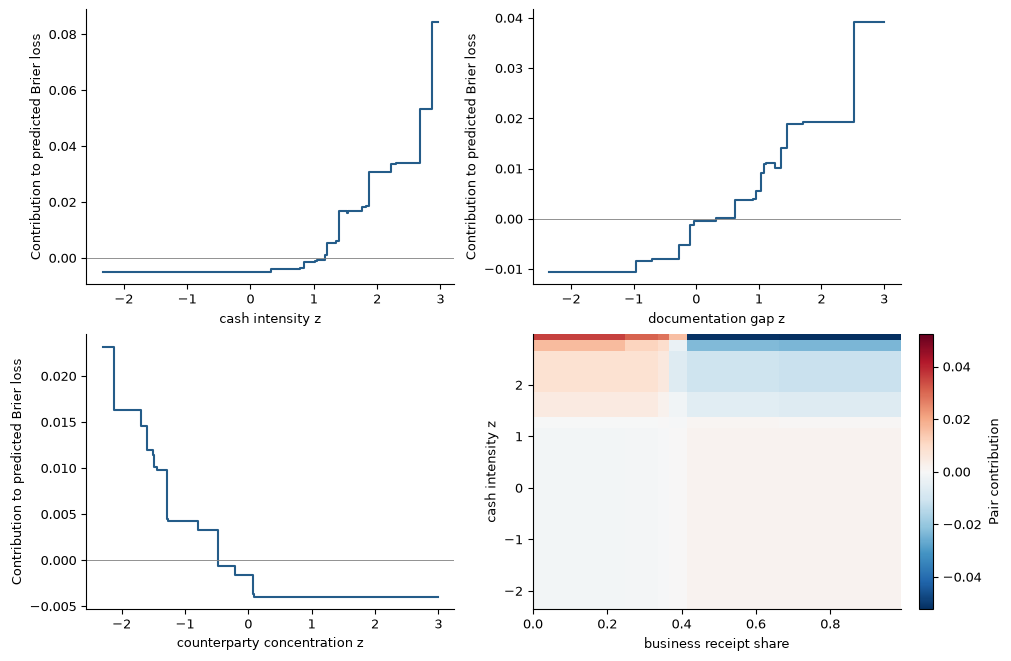

In [13]:
from ch02_helpers import fanova_class
fanova = fanova_class(clus)(aux, Xd).purified("product_marginals")
np.testing.assert_allclose(fanova.predict(Xd), aux.predict(Xd), atol=3e-6)
main_importance = np.array([np.dot(v * v, w) for v, w in zip(fanova.main, fanova.marginal)])
pair_importance = {pair: float(np.sum(v * v * np.outer(fanova.marginal[pair[0]], fanova.marginal[pair[1]])))
                   for pair, v in fanova.pair.items()}
top_main = np.argsort(-main_importance)[:3].tolist()
top_pair = max(pair_importance, key=pair_importance.get)
assert [features[j] for j in top_main] == clus["fanova"]["top_main"] == ["cash_intensity_z", "documentation_gap_z", "counterparty_concentration_z"]
assert [features[j] for j in top_pair] == clus["fanova"]["top_pair"] == ["business_receipt_share", "cash_intensity_z"]
np.testing.assert_allclose(main_importance, clus["fanova"]["main_variances"], rtol=1e-9)

with plt.rc_context({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False}):
    fig, axs = plt.subplots(2, 2, figsize=(10, 6.5), constrained_layout=True)
    for ax, j in zip(axs.flat, top_main):
        low, high = np.quantile(Xd.iloc[:, j], [.01, .99])
        grid = np.linspace(low, high, 300)
        ax.step(grid, fanova.main[j][np.searchsorted(fanova.cuts[j], grid, side="right")], where="post", color="#245c89")
        ax.axhline(0, color="gray", linewidth=.6)
        ax.set(xlabel=features[j].replace("_", " "), ylabel="Contribution to predicted Brier loss")
    ax = axs.flat[3]
    j, k = top_pair
    a = np.linspace(*np.quantile(Xd.iloc[:, j], [.01, .99]), 100)
    b = np.linspace(*np.quantile(Xd.iloc[:, k], [.01, .99]), 100)
    z = fanova.pair[j, k][np.searchsorted(fanova.cuts[j], a, side="right")[:, None],
                          np.searchsorted(fanova.cuts[k], b, side="right")[None, :]]
    limit = max(abs(z.min()), abs(z.max()))
    im = ax.pcolormesh(a, b, z.T, shading="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set(xlabel=features[j].replace("_", " "), ylabel=features[k].replace("_", " "))
    fig.colorbar(im, ax=ax, label="Pair contribution")
    plt.show()

**Read the output.** The recomputed decomposition matches the recorded one and reproduces Figure 2.3 of the chapter. Cash intensity, documentation gap and counterparty concentration have the largest main-effect variances. Business-receipt share with cash intensity has the largest pair-effect variance. Cash intensity therefore appears both as the strongest separator of the region's membership and as the leading main effect of the fitted loss model. A curve above zero adds to predicted loss relative to the reference mean; the heatmap shows where the joint contribution adds or subtracts beyond the main effects. Product marginals can combine feature values that rarely occur together in the correlated AML population. These plots explain the fitted auxiliary function under that reference and do not establish causal effects or rule out higher-order structure in the underlying loss mechanism.

## Plot the measured regions

The final plot, Figure 2.4 of the chapter, returns from auxiliary-model interpretation to measured logistic-model loss. Each bar is one frozen cluster's mean confirmation Brier loss. Black dots show discovery means for those same cluster rules, the red bar marks the discovery-selected region and labels above the bars give confirmation population shares. The dashed line is overall confirmation mean loss.

The code reads the saved cluster summaries whose means were checked against recomputed losses earlier. It uses identical cluster positions for the bars and dots so their comparison preserves region identity. The plot summarizes severity and extent, although bar width is constant and does not encode cluster size.

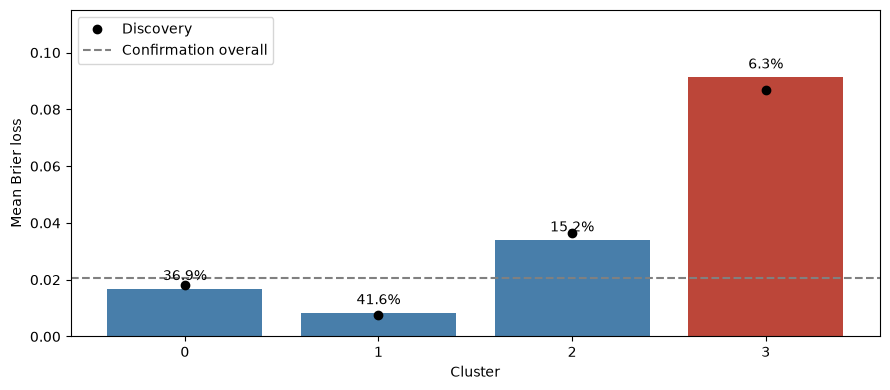

In [14]:
crow=geo["confirmation"]["leaf_output"]["clusters"]
fig,ax=plt.subplots(figsize=(9,4))
ax.bar(range(4),[r["brier"] for r in crow],color=["#bc4639" if i==chosen else "#487eaa" for i in range(4)])
ax.plot(range(4),[r["brier"] for r in geo["arms"]["leaf_output"]["discovery"]["clusters"]],"ko",label="Discovery")
ax.axhline(geo_loss.mean(),color="gray",linestyle="--",label="Confirmation overall")
for i,r in enumerate(crow):ax.text(i,r["brier"]+.003,f"{r['share']:.1%}",ha="center")
ax.set(xlabel="Cluster",ylabel="Mean Brier loss",xticks=range(4),ylim=(0,.115))
ax.legend();plt.tight_layout();plt.show()

**Read the output.** The figure reproduces Figure 2.4 of the chapter. Cluster 3 has mean confirmation loss 0.091412 in 6.29% of observations, far above the dashed overall mean of 0.020636. The overall mean is the share-weighted average of the cluster means, so a small high-loss region contributes little to it. Discovery dots lie close to the confirmation bars for all four clusters. The figure has no error bars; the uncertainty of the selected contrast is given in the confirmation cell, and visual separation alone is not a significance test.

## From one shot to the discovery loop

The completed assessment constructed one partition, selected its weakest eligible region on discovery and measured the frozen choice on confirmation. In the book's terms, the medoid tuple defines a candidate partition in the Inner Array. The adapter assigns observations to its regions, and the evaluator returns observed losses and support. The declared sample supplies the evaluation condition; the resulting score table is an output, not the Outer Array itself. Discovery and confirmation have distinct roles even though both come from the stated synthetic population.

An adaptive search would construct further medoid tuples using discovery feedback, evaluate them under the same measurement contract and compare their regional severity and coverage. A Pareto frontier would retain candidates for which no other evaluated candidate is at least as good on both declared objectives and strictly better on one. No such frontier is computed here. Chapter 3 develops that search step; this notebook establishes the assignment and measurement machinery it needs.

The seed-62624 confirmation outcomes have now been inspected. Using them to alter the geometry, support thresholds or selected cluster would turn them into development evidence. A revised rule would need fresh reserved confirmation. The corrected weighted-leaf result here also belongs to a separate run from the historical adaptive-loop results replayed in other companions.


## What to try

1. **Leaf membership and distance.** In a separate scratch cell, change tree 0's leaf 7 value from 0.2 to 0.4. Predict A–B proximity and squared distance before calculating them. Check: proximity remains 0.01 because the changed leaf is not shared; squared distance becomes 0.20. Keep the original toy cell intact so its recorded assertions still apply.
2. **Construction and selection.** Explain why PAM can find a compact partition without knowing which cluster has the largest measured loss. Use `discovery_table` to calculate each region's contrast as `brier - rest_brier`. Compare the rankings by regional Brier and contrast, and state why changing the selection criterion defines a different procedure even if the same cluster wins on this sample.
3. **Severity and extent.** Use the saved confirmation table descriptively to verify that summing `share * brier` over clusters gives `geo_loss.mean()`. Then calculate the selected region's fraction of total loss as `share * brier / geo_loss.mean()`. Explain why its fraction of loss can exceed its fraction of observations. Do not use these confirmation calculations to select another region.
4. **Different validation questions.** Brier loss measures probability error, AUC measures ranking and captured loss measures the fraction of total loss occurring in a region. Explain how a region could rank outcomes reasonably well and still have elevated Brier loss. Consult the chapter's event-rate discussion before interpreting loss as a calibration defect.
5. **Reading the explanation.** Choose a main-effect panel and describe a range with a positive fitted contribution. Then explain why the curve and the region's feature profile answer different questions. State what would remain unestablished about a causal intervention on that feature.
